In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pydas.controllers import SupplyController
from pydas.RCBuildings import RCBuilding1R1C
from pydas.utilities import ClimateData

thermal_resistances = {"R1": 2.0} # Thermal resistance in K / Kw.
thermal_capacitances = {"C1": 5.0} # Thermal resistance in kwH / K.

In [2]:
controller = SupplyController(maximum_heating_power = 10.0) # An external "controller" that supplies heating power instantaneously.
rcbuilding = RCBuilding1R1C(timestep = 1.0, thermal_resistances = thermal_resistances, thermal_capacitances = thermal_capacitances) # Represent a 1R1C model of building heat loss as first test.
df_air_temp = ClimateData.load_csv_from_smhi("../data/smhi_got_lufttemperatur.csv")

In [3]:
recorded_indoor_temperatures = []
recorded_setpoints = []
number_of_iterations = len(df_air_temp.index)
print(f"Simulation will contain {number_of_iterations} one-hour timesteps.")

Simulation will contain 3141 one-hour timesteps.


In [4]:
%%time
for it in range(number_of_iterations):
    current_timestep = rcbuilding.current_timestep
    time_of_day = df_air_temp["timestamp"].dt.hour[it]
    recorded_setpoints.append(rcbuilding.get_day_night_setpoint(time_of_day)) # Get the current setpoint temperature, based on a very simple rule.
    recorded_indoor_temperatures.append(rcbuilding.state["indoor_temperature"]) # Get the corresponding instantaneous indoor temperature.
    current_outdoor_temperature = df_air_temp["Lufttemperatur"][current_timestep]
    current_external_heating = controller.setpoint_schedule(rcbuilding = rcbuilding, time_of_day = time_of_day)
    rcbuilding.step(current_external_heating = current_external_heating, current_outdoor_temperature = current_outdoor_temperature) # Update the simulation one hour forward (one timestep).

CPU times: total: 453 ms
Wall time: 468 ms


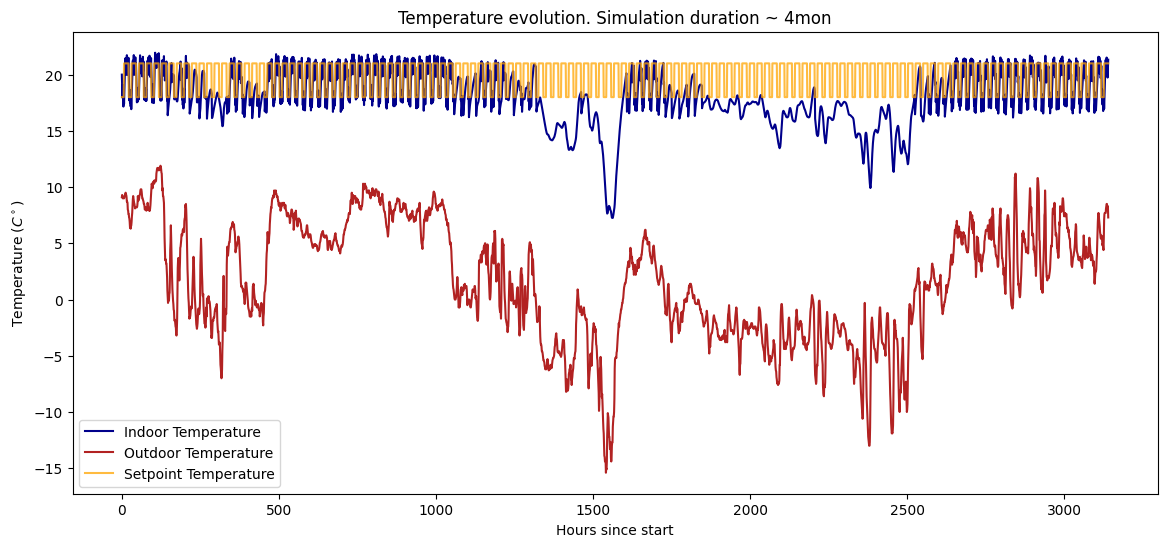

In [5]:
plt.figure(figsize = (14, 6))
plt.plot(recorded_indoor_temperatures, label = "Indoor Temperature", color = "darkblue")
plt.plot(df_air_temp["Lufttemperatur"], label = "Outdoor Temperature", color = "firebrick")
plt.plot(recorded_setpoints, color = "orange", label = "Setpoint Temperature", alpha = 0.75)
plt.title("Temperature evolution. Simulation duration ~ 4mon")
plt.xlabel("Hours since start")
plt.ylabel("Temperature $(C^\\circ)$")
plt.legend()

#plt.xlim(1000, 1500)